In [3]:
import numpy as np
import scipy as sc
import pandas as pd
import re
import os
import math
from math import factorial
import sys
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mticker

from numpy import log10
import random
import warnings

from IPython.utils import io
from IPython.core.display import HTML
from itertools import product
import time
import PIL
import joblib
from collections import Counter

from scipy.stats import linregress, gaussian_kde, skew, gmean, skewtest
from scipy.stats import pareto
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
from scipy.spatial import distance
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.signal import find_peaks
from sklearn.preprocessing import PowerTransformer
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings('ignore')
%config InlineBackend.figure_formats = ['svg']
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

display(HTML(
    '<style>'
        '#notebook { padding-top:50px !important; padding-right:50px !important; padding-left:50px !important;} ' 
        '.container { width:100% !important; } '
        '.end_space { min-height:0px !important; } '
    '</style>'
))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


stars_dir = '~/GitHub/stars-data-builder/'


def get_skew(dat, method='moment', q=(0.1, 0.5, 0.9)):
    """
    Compute skewness using different definitions.

    Parameters
    ----------
    dat : array-like
        1D numeric data.
    method : {'moment','Bowley','generalized_quantile','L-moment'}
    q : tuple
        Quantiles used for generalized quantile skewness (default: 10–50–90).

    Returns
    -------
    float
        Skewness estimate (np.nan if undefined).
    """
    x = np.asarray(dat, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n < 3:
        return np.nan

    if method == 'moment':
        return stats.skew(x, bias=False)

    elif method == 'Bowley':
        q1, q2, q3 = np.percentile(x, [25, 50, 75])
        denom = q3 - q1
        return np.nan if denom == 0 else (q3 + q1 - 2*q2) / denom

    elif method == 'generalized_quantile':
        ql, qm, qh = np.quantile(x, q)
        denom = qh - ql
        return np.nan if denom == 0 else (qh + ql - 2*qm) / denom

    elif method == 'L-moment':
        # L-moment skewness τ3 = l3 / l2
        x_sorted = np.sort(x)
        b0 = np.mean(x_sorted)
        b1 = np.mean([(i/(n-1))*x_sorted[i] for i in range(n)])
        b2 = np.mean([(i*(i-1))/((n-1)*(n-2))*x_sorted[i]
                      for i in range(n)])

        l1 = b0
        l2 = 2*b1 - b0
        l3 = 6*b2 - 6*b1 + b0

        return np.nan if l2 == 0 else l3 / l2

    else:
        raise ValueError(f"Unknown method: {method}")




def yeojohnson_inverse_single(y, lmbda):
    if y >= 0:
        return ((y * lmbda) + 1) ** (1 / lmbda) - 1 if lmbda != 0 else np.exp(y) - 1
    else:
        return 1 - ((-(y * (2 - lmbda))) + 1) ** (1 / (2 - lmbda)) if lmbda != 2 else 1 - np.exp(-y)


def iq_range(x):
    x_clean = x[~np.isnan(x)]
    if x_clean.size == 0:
        return np.nan
    q75, q25 = np.percentile(x_clean, [75, 25])
    return q75 - q25
    
def sbts(bt_mean, raw_median, iqr):
    """
    Standardized Back-Transform Shift (SBTS)
    """
    return 100 * abs(bt_mean - raw_median)/iqr


# -----------------------------
# Signed Power Transform & Inverse
# -----------------------------


def signed_power(x, p):
    x_arr = np.asarray(x, dtype=float)
    t = np.empty_like(x_arr)
    pos = x_arr >= 0
    neg = ~pos
    if p == 0:
        t[pos] = np.log1p(x_arr[pos])
        t[neg] = -np.log1p(-x_arr[neg])
    else:
        t[pos] = np.power(x_arr[pos], p)
        t[neg] = -np.power(-x_arr[neg], p)
    return t.item() if np.isscalar(x) else t

def signed_power_inv(t, p, eps=1e-8):
    t_arr = np.asarray(t, dtype=float)
    x = np.empty_like(t_arr)
    pos = t_arr >= 0
    neg = ~pos

    if p == 0:
        x[pos] = np.expm1(t_arr[pos])
        x[neg] = -np.expm1(-t_arr[neg])
    else:
        x[pos] = np.power(np.maximum(t_arr[pos], eps), 1 / p)
        x[neg] = -np.power(np.maximum(-t_arr[neg], eps), 1 / p)

    return x.item() if np.isscalar(t) else x


# -----------------------------
# Optimized Chain Transformation (OCT)
# -----------------------------
def OCT(x, alpha=1, eps=1e-8):
    """
    Apply logit-arctan chain transformation after signed power.
    Returns transformed array and parameters needed for test set transformation.
    """
    x = np.asarray(x, dtype=float)
    x_alpha = signed_power(x, alpha)
    lower, upper = np.min(x_alpha), np.max(x_alpha)
    gl = np.log((x_alpha - lower + eps) / (upper - x_alpha + eps))
    gl_mean, gl_std = np.mean(gl), np.std(gl)
    if np.isclose(gl_std, 0):
        gl_std = eps
    transformed = np.arctan(alpha * (gl - gl_mean) / gl_std)
    return transformed, gl_mean, gl_std, lower, upper


def optimize_OCT_alpha(x_train, alpha_bounds=(1e-5, 100)):
    """Find alpha that minimizes a statistic (closer to normality)."""
    if len(x_train) < 8:
        return 1.0

    def objective(alpha):
        transformed, *_ = OCT(x_train, alpha=alpha)
        return stats.anderson(transformed).statistic
        #return stats.normaltest(transformed).statistic
        #return stats.shapiro(transformed).statistic
        
    res = minimize_scalar(objective, bounds=alpha_bounds, method='bounded')
    return res.x if res.success else 1.0




def passed_AD(dat, alpha=0.05, n_resample=1000, sample_size=100, random_state=0):
    """
    Returns the proportion of bootstrap samples that pass the Anderson–Darling normality test.
    Pass = cannot reject normality at level alpha.
    Sampling is with replacement (classic bootstrap).
    """
    rng = np.random.default_rng(random_state)
    dat = np.asarray(dat, dtype=float)
    n = len(dat)
    if n < 10:
        return np.nan  # not enough data for AD

    passes = 0
    sig_levels_default = np.array([15, 10, 5, 2.5, 1])  # percent, per scipy

    for _ in range(n_resample):
        sample = rng.choice(dat, size=sample_size, replace=True)
        res = stats.anderson(sample)
        stat = res.statistic
        cvals = np.array(res.critical_values)
        sig_levels = np.array(res.significance_level)  # in percent

        # Find closest significance level to desired alpha
        target = 100 * alpha
        idx = np.argmin(np.abs(sig_levels - target))
        crit_val = cvals[idx]

        if stat < crit_val:
            passes += 1

    return passes / n_resample


def passed_DAP(dat, alpha=0.05, n_resample=1000, sample_size=100, random_state=0):
    """
    Returns the proportion of bootstrap samples that pass the D’Agostino–Pearson normality test.
    Pass = cannot reject normality at level alpha.
    Sampling is with replacement (classic bootstrap).
    """
    rng = np.random.default_rng(random_state)
    dat = np.asarray(dat, dtype=float)
    n = len(dat)
    if n < 10:
        return np.nan  # not enough data for DAP

    passes = 0
    for _ in range(n_resample):
        sample = rng.choice(dat, size=min(sample_size, n), replace=True)
        _, p = stats.normaltest(sample)
        if p >= alpha:
            passes += 1

    return passes / n_resample


def obs_pred_rsquare(obs, pred):
    """Pseudo R² for observed vs predicted (1:1 fit)."""
    return 1 - np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2)

def qq_rsquare(sample, dist='norm'):
    """Compute pseudo R² for Q–Q plot against a theoretical distribution."""
    sample = np.sort(sample)
    n = len(sample)
    probs = (np.arange(1, n + 1) - 0.5) / n

    # Theoretical quantiles, rescaled to sample's mean and std
    theoretical = getattr(stats, dist).ppf(probs)
    pred = np.mean(sample) + np.std(sample, ddof=1) * theoretical

    return obs_pred_rsquare(sample, pred)




def trim_edges(data, method='minmax', q=0.01):
    """
    Trim extreme values from data.
    
    method: 'minmax' removes exact min/max
            'quantile' removes lower/upper q-quantile
    q: fraction to trim for 'quantile'
    """
    data = np.asarray(data, dtype=float)
    if len(data) <= 2:
        return data
    
    if method == 'minmax':
        min_val, max_val = np.nanmin(data), np.nanmax(data)
        return data[(data != min_val) & (data != max_val)]
    elif method == 'quantile':
        lower, upper = np.nanquantile(data, [q, 1 - q])
        return data[(data >= lower) & (data <= upper)]
    else:
        raise ValueError("Invalid trim method")


        

# -----------------------------
# Ordered Quantile Normalization (ORQ)
# -----------------------------
class OrderQuantileTransform:
    """
    Forward and inverse transform for Ordered Quantile Normalization.
    Similar to bestNormalize::orderNorm in R.
    Handles ties and allows back-transformable mean.
    """
    def __init__(self):
        self.sorted_values = None
        self.normal_quantiles = None
        self.ranks = None

    def fit(self, x):
        x = np.asarray(x, dtype=float)
        finite_mask = np.isfinite(x)
        if not finite_mask.any():
            raise ValueError("Input contains no finite values")

        x_finite = x[finite_mask]
        n = len(x_finite)

        # --- ranks with average for ties ---
        self.ranks = stats.rankdata(x_finite, method='average')
        # --- store sorted values ---
        self.sorted_values = np.sort(x_finite)

        # --- map ranks to standard normal quantiles ---
        self.normal_quantiles = stats.norm.ppf((self.ranks - 0.5) / n)
        return self

    def transform(self, x):
        x = np.asarray(x, dtype=float)
        finite_mask = np.isfinite(x)
        y = np.full_like(x, np.nan, dtype=float)

        x_finite = x[finite_mask]
        # --- ranks relative to sorted training values ---
        ranks = np.searchsorted(self.sorted_values, x_finite, side='left') + 1
        n = len(self.sorted_values)
        ranks = np.clip(ranks, 1, n)
        y[finite_mask] = stats.norm.ppf((ranks - 0.5) / n)
        return y

    def inverse_transform(self, y):
        y = np.asarray(y, dtype=float)
        finite_mask = np.isfinite(y)
        x_inv = np.full_like(y, np.nan, dtype=float)
        if self.normal_quantiles is None or self.sorted_values is None:
            raise ValueError("Transformer has not been fitted")

        x_inv[finite_mask] = np.interp(y[finite_mask],
                                       self.normal_quantiles,
                                       self.sorted_values,
                                       left=self.sorted_values[0],
                                       right=self.sorted_values[-1])
        return x_inv

# -----------------------------
# Helper to apply ORQ with optional shift/reflection
# -----------------------------
def apply_ORQ_transform(x, shift=0, reflect=False):
    """
    Apply Ordered Quantile Normalization with optional shift and reflection.
    Returns transformed array and fitted ORQ object for inversion.
    """
    x = np.asarray(x, dtype=float)
    if shift != 0:
        x = x + shift
    if reflect:
        x = np.max(x) - x
    orq = OrderQuantileTransform().fit(x)
    x_orq = orq.transform(x)
    return x_orq, orq

## Load data
This is the same data that gets loaded into the app

In [4]:
main_df = pd.read_pickle(stars_dir + 'FilesForApp/hosp_stars_dat.pkl')
print(main_df.shape)
main_df.head()

(18386, 270)


,Facility ID,Facility Name,Address,City,State,ZIP Code,County Name,Hospital Type,Hospital Ownership,file_month,file_year,Std_Outcomes_Mortality_score,Std_Outcomes_Readmission_score,Std_Outcomes_Safety_score,Std_PatientExp_score,Std_Process_score,std_weight_PatientExperience,std_weight_Readmission,std_weight_Mortality,std_weight_safety,std_weight_Process,weight_PatientExperience,weight_Outcomes_Readmission,weight_Outcomes_Mortality,weight_Outcomes_Safety,weight_Process,summary_score,Outcomes_Mortality_cnt,Outcomes_safety_cnt,Outcomes_Readmission_cnt,Patient_Experience_cnt,Process_cnt,Total_measure_group_cnt,MortSafe_Group_cnt,report_indicator,cnt_grp,star,Q_25,Release year,std_MORT_30_AMI,std_MORT_30_CABG,std_MORT_30_COPD,std_MORT_30_HF,std_MORT_30_PN,std_MORT_30_STK,std_PSI_4_SURG_COMP,std_Hybrid_HWM,mortality_C8,mortality_measure_wt,std_EDAC_30_AMI,std_EDAC_30_HF,std_EDAC_30_PN,std_OP_32,std_READM_30_CABG,std_READM_30_COPD,std_READM_30_HIP_KNEE,std_OP_35_ADM,std_OP_35_ED,std_OP_36,std_Hybrid_HWR,readmission_measure_wt,std_COMP_HIP_KNEE,std_HAI_1,std_HAI_2,std_HAI_3,std_HAI_4,std_HAI_5,std_HAI_6,std_PSI_90_SAFETY,safety_measure_wt,std_IMM_3,std_OP_10,std_OP_13,std_OP_18B,std_OP_22,std_OP_23,std_OP_29,std_OP_8,std_SAFE_USE_OF_OPIOIDS,std_SEP_1,process_measure_wt,std_O_COMP_1_LINEAR_SCORE,std_O_COMP_2_LINEAR_SCORE,std_O_COMP_3_LINEAR_SCORE,std_O_PATIENT_RATE_LINEAR_SCORE,std_O_PATIENT_REC_LINEAR_SCORE,std_H_COMP_1_LINEAR_SCORE,std_H_COMP_2_LINEAR_SCORE,std_H_COMP_3_LINEAR_SCORE,std_H_COMP_5_LINEAR_SCORE,std_H_COMP_6_LINEAR_SCORE,std_H_COMP_7_LINEAR_SCORE,std_H_CLEAN_LINEAR_SCORE,std_H_QUIET_LINEAR_SCORE,std_H_RECMND_LINEAR_SCORE,std_H_HSP_RATING_LINEAR_SCORE,patient_exp_C9,patient_exp_C10,patient_exp_C11,patient_exp_C12,patient_exp_C13,patient_exp_C14,patient_exp_C15,patient_exp_measure_wt,std_READM_30_HOSP_WIDE,std_HCP_COVID_19,std_PC_01,std_H_COMP_1_STAR_RATING,std_H_COMP_2_STAR_RATING,std_H_COMP_3_STAR_RATING,std_H_COMP_5_STAR_RATING,std_H_COMP_6_STAR_RATING,std_H_COMP_7_STAR_RATING,std_H_GLOB_STAR_RATING,std_H_INDI_STAR_RATING,std_OP_3B,std_OP_33,std_OP_30,std_ED_2B,IMM_3,OP_18B,OP_22,OP_23,OP_29,SEP_1,SAFE_USE_OF_OPIOIDS,MORT_30_AMI,MORT_30_CABG,MORT_30_COPD,MORT_30_HF,MORT_30_PN,MORT_30_STK,PSI_4_SURG_COMP,COMP_HIP_KNEE,PSI_90_SAFETY,Hybrid_HWM,H_COMP_1_A_P,H_COMP_1_SN_P,H_COMP_1_U_P,H_COMP_1_LINEAR_SCORE,H_COMP_1_STAR_RATING,H_NURSE_RESPECT_A_P,H_NURSE_RESPECT_SN_P,H_NURSE_RESPECT_U_P,H_NURSE_LISTEN_A_P,H_NURSE_LISTEN_SN_P,H_NURSE_LISTEN_U_P,H_NURSE_EXPLAIN_A_P,H_NURSE_EXPLAIN_SN_P,H_NURSE_EXPLAIN_U_P,H_COMP_2_A_P,H_COMP_2_SN_P,H_COMP_2_U_P,H_COMP_2_LINEAR_SCORE,H_COMP_2_STAR_RATING,H_DOCTOR_RESPECT_A_P,H_DOCTOR_RESPECT_SN_P,H_DOCTOR_RESPECT_U_P,H_DOCTOR_LISTEN_A_P,H_DOCTOR_LISTEN_SN_P,H_DOCTOR_LISTEN_U_P,H_DOCTOR_EXPLAIN_A_P,H_DOCTOR_EXPLAIN_SN_P,H_DOCTOR_EXPLAIN_U_P,H_COMP_3_A_P,H_COMP_3_SN_P,H_COMP_3_U_P,H_COMP_3_LINEAR_SCORE,H_COMP_3_STAR_RATING,H_CALL_BUTTON_A_P,H_CALL_BUTTON_SN_P,H_CALL_BUTTON_U_P,H_BATH_HELP_A_P,H_BATH_HELP_SN_P,H_BATH_HELP_U_P,H_COMP_5_A_P,H_COMP_5_SN_P,H_COMP_5_U_P,H_COMP_5_LINEAR_SCORE,H_COMP_5_STAR_RATING,H_MED_FOR_A_P,H_MED_FOR_SN_P,H_MED_FOR_U_P,H_SIDE_EFFECTS_A_P,H_SIDE_EFFECTS_SN_P,H_SIDE_EFFECTS_U_P,H_COMP_6_N_P,H_COMP_6_Y_P,H_COMP_6_LINEAR_SCORE,H_COMP_6_STAR_RATING,H_DISCH_HELP_N_P,H_DISCH_HELP_Y_P,H_SYMPTOMS_N_P,H_SYMPTOMS_Y_P,H_COMP_7_A,H_COMP_7_D_SD,H_COMP_7_SA,H_COMP_7_LINEAR_SCORE,H_COMP_7_STAR_RATING,H_CT_PREFER_A,H_CT_PREFER_D_SD,H_CT_PREFER_SA,H_CT_UNDER_A,H_CT_UNDER_D_SD,H_CT_UNDER_SA,H_CT_MED_A,H_CT_MED_D_SD,H_CT_MED_SA,H_CLEAN_HSP_A_P,H_CLEAN_HSP_SN_P,H_CLEAN_HSP_U_P,H_CLEAN_LINEAR_SCORE,H_CLEAN_STAR_RATING,H_QUIET_HSP_A_P,H_QUIET_HSP_SN_P,H_QUIET_HSP_U_P,H_QUIET_LINEAR_SCORE,H_QUIET_STAR_RATING,H_HSP_RATING_0_6,H_HSP_RATING_7_8,H_HSP_RATING_9_10,H_HSP_RATING_LINEAR_SCORE,H_HSP_RATING_STAR_RATING,H_RECMND_DN,H_RECMND_DY,H_RECMND_PY,H_RECMND_LINEAR_SCORE,H_RECMND_STAR_RATING,H_STAR_RATING,O_COMP_1_LINEAR_SCORE,O_COMP_2_LINEAR_SCORE,O_COMP_3_LINEAR_SCORE,O_PATIENT_RATE_LINEAR_SC

In [5]:
tdf = main_df[main_df['Release year'] == '2026'] 
print(tdf.shape)
tdf = tdf.dropna(axis=1, how='all')
print(tdf.shape)

#for l in list(tdf):
    #print("'"+l+"',")

(3210, 270)
(3210, 160)


IMM_3                        | RAW: Highly     left-skewed (L-skew = -0.218)
IMM_3                        | OCT: Negligibly right-skewed (L-skew = 0.044)
Decrease in absolute skew: 79.7%


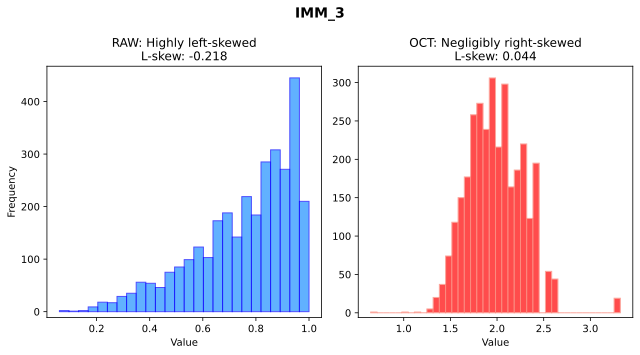




OP_18B                       | RAW: Slightly   right-skewed (L-skew = 0.138)
OP_18B                       | OCT: Negligibly right-skewed (L-skew = 0.044)
Decrease in absolute skew: 68.0%


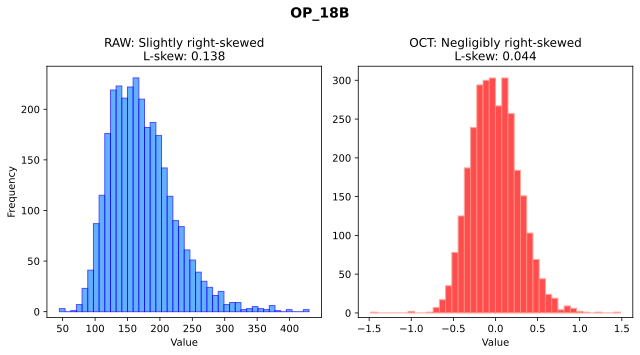




OP_22                        | RAW: Extremely  right-skewed (L-skew = 0.328)
OP_22                        | OCT: Moderately left-skewed (L-skew = -0.170)
Decrease in absolute skew: 48.1%


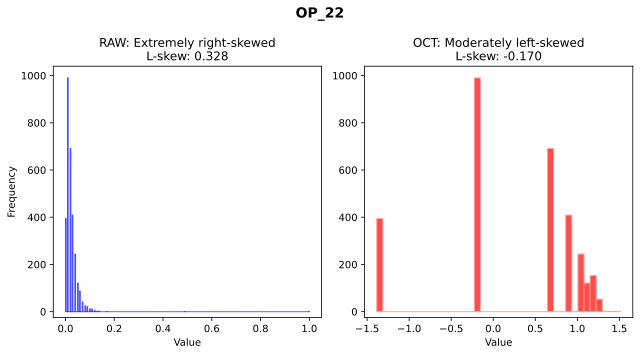




OP_23                        | RAW: Moderately left-skewed (L-skew = -0.161)
OP_23                        | OCT: Moderately right-skewed (L-skew = 0.154)
Decrease in absolute skew: 4.4%


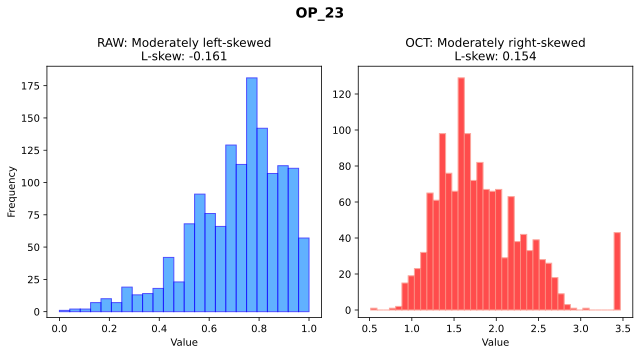




OP_29                        | RAW: Extremely  left-skewed (L-skew = -0.503)
OP_29                        | OCT: Highly     right-skewed (L-skew = 0.212)
Decrease in absolute skew: 57.8%


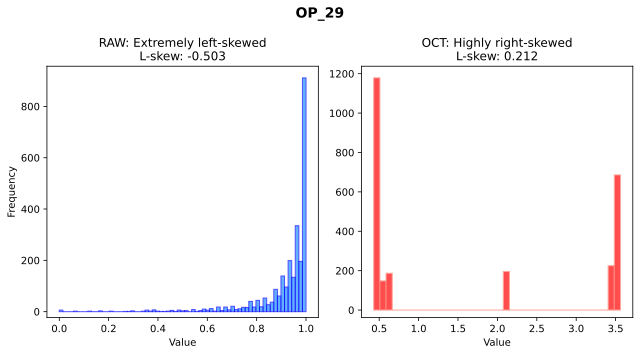




OP_35_ADM                    | RAW: Slightly   right-skewed (L-skew = 0.122)
OP_35_ADM                    | OCT: Negligibly right-skewed (L-skew = 0.057)
Decrease in absolute skew: 53.2%


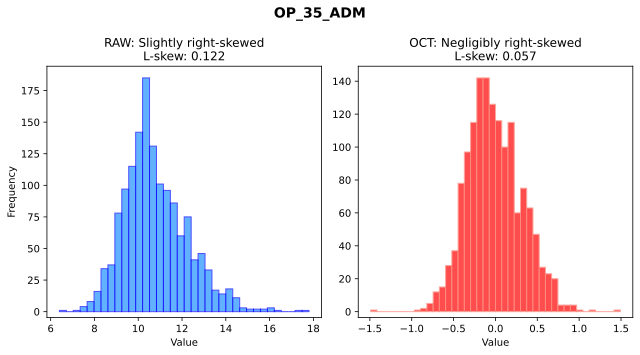




OP_35_ED                     | RAW: Slightly   right-skewed (L-skew = 0.104)
OP_35_ED                     | OCT: Negligibly right-skewed (L-skew = 0.027)
Decrease in absolute skew: 73.7%


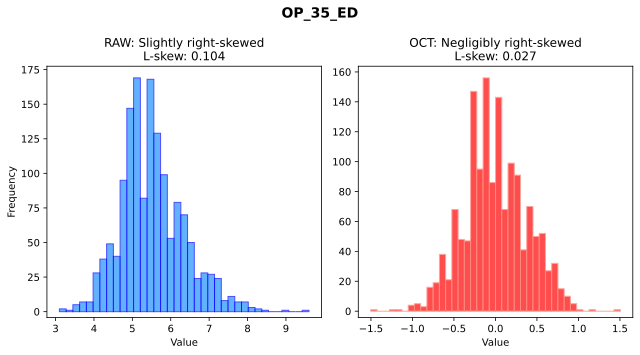




OP_36                        | RAW: Highly     right-skewed (L-skew = 0.201)
OP_36                        | OCT: Negligibly left-skewed (L-skew = -0.018)
Decrease in absolute skew: 90.9%


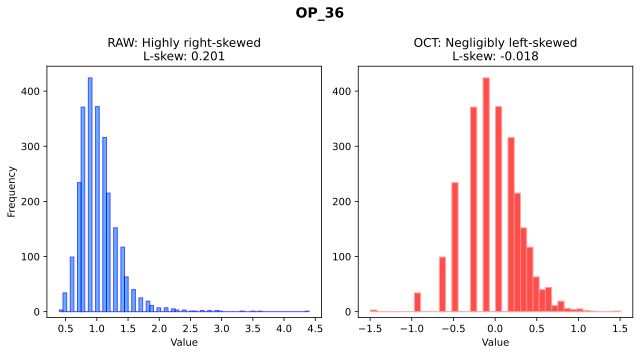




HAI_1                        | RAW: Highly     right-skewed (L-skew = 0.216)
HAI_1                        | OCT: Highly     left-skewed (L-skew = -0.276)
Decrease in absolute skew: -28.1%


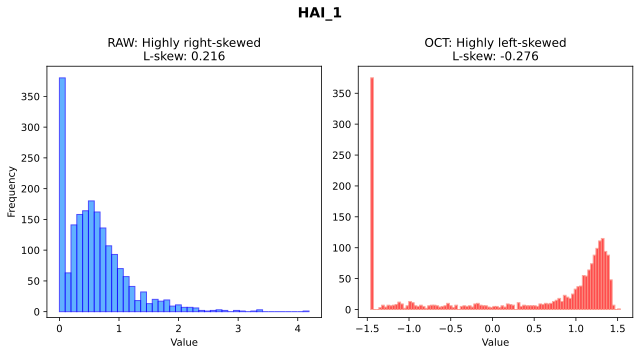




HAI_2                        | RAW: Highly     right-skewed (L-skew = 0.249)
HAI_2                        | OCT: Highly     left-skewed (L-skew = -0.212)
Decrease in absolute skew: 15.0%


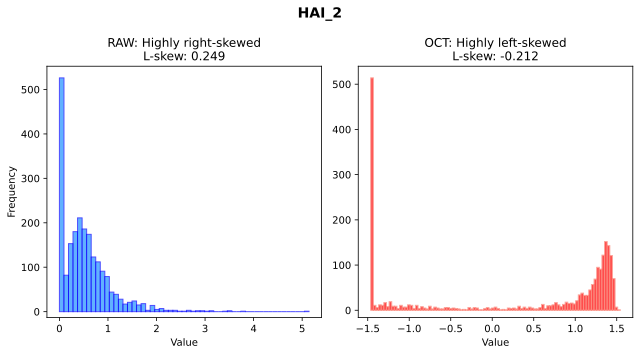




HAI_3                        | RAW: Moderately right-skewed (L-skew = 0.189)
HAI_3                        | OCT: Highly     left-skewed (L-skew = -0.298)
Decrease in absolute skew: -58.0%


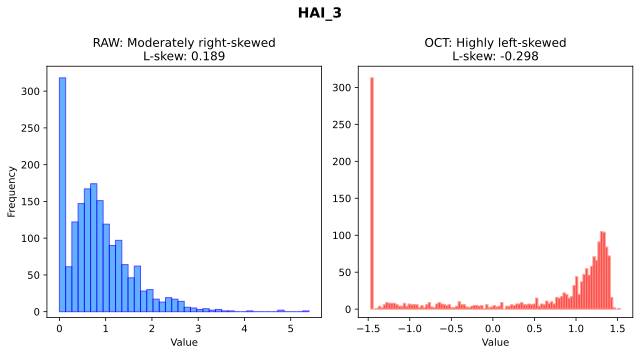




HAI_4                        | RAW: Highly     right-skewed (L-skew = 0.223)
HAI_4                        | OCT: Highly     left-skewed (L-skew = -0.265)
Decrease in absolute skew: -19.0%


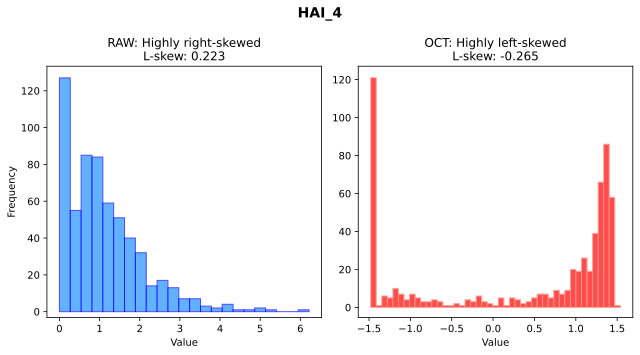




HAI_5                        | RAW: Highly     right-skewed (L-skew = 0.209)
HAI_5                        | OCT: Highly     left-skewed (L-skew = -0.270)
Decrease in absolute skew: -29.5%


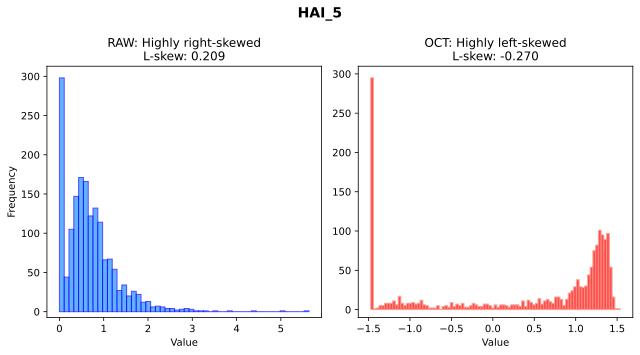




HAI_6                        | RAW: Highly     right-skewed (L-skew = 0.284)
HAI_6                        | OCT: Highly     left-skewed (L-skew = -0.280)
Decrease in absolute skew: 1.3%


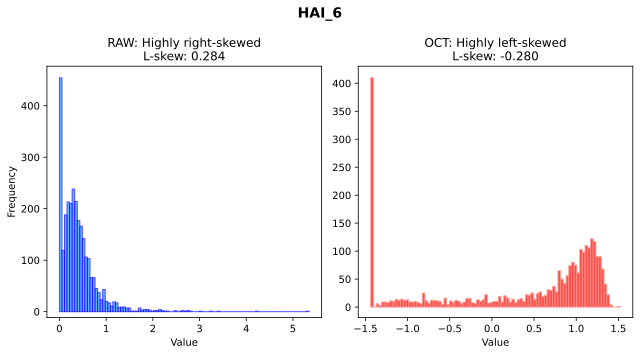




OP_10                        | RAW: Highly     right-skewed (L-skew = 0.223)
OP_10                        | OCT: Moderately left-skewed (L-skew = -0.154)
Decrease in absolute skew: 30.7%


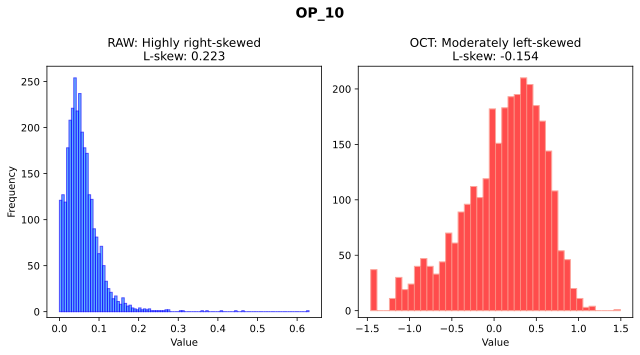




MORT_30_CABG                 | RAW: Highly     right-skewed (L-skew = 0.229)
MORT_30_CABG                 | OCT: Negligibly right-skewed (L-skew = 0.073)
Decrease in absolute skew: 68.3%


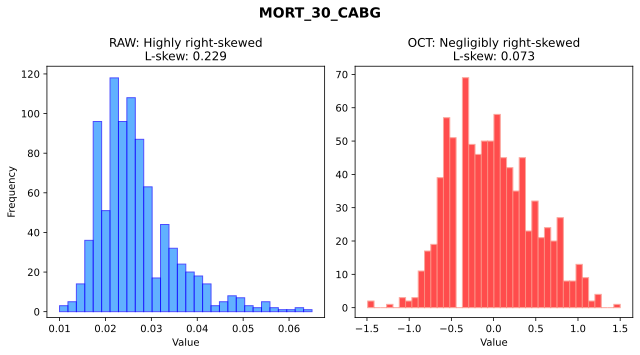




COMP_HIP_KNEE                | RAW: Slightly   right-skewed (L-skew = 0.113)
COMP_HIP_KNEE                | OCT: Negligibly right-skewed (L-skew = 0.012)
Decrease in absolute skew: 89.6%


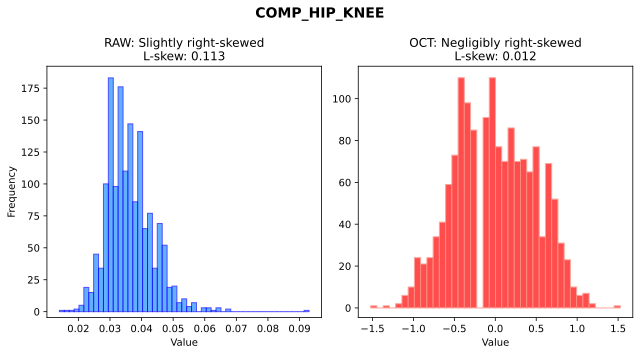




PSI_90_SAFETY                | RAW: Highly     right-skewed (L-skew = 0.245)
PSI_90_SAFETY                | OCT: Negligibly right-skewed (L-skew = 0.087)
Decrease in absolute skew: 64.5%


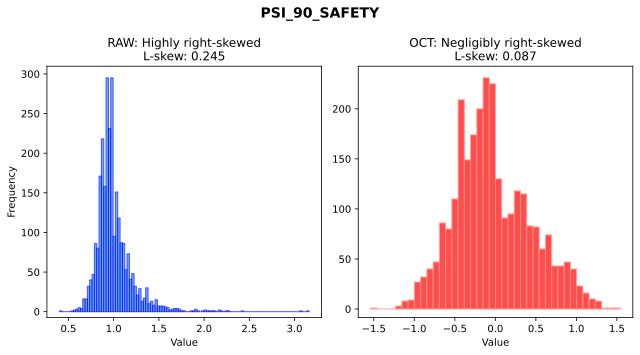




H_COMP_6_LINEAR_SCORE        | RAW: Slightly   left-skewed (L-skew = -0.112)
H_COMP_6_LINEAR_SCORE        | OCT: Negligibly left-skewed (L-skew = -0.053)
Decrease in absolute skew: 52.6%


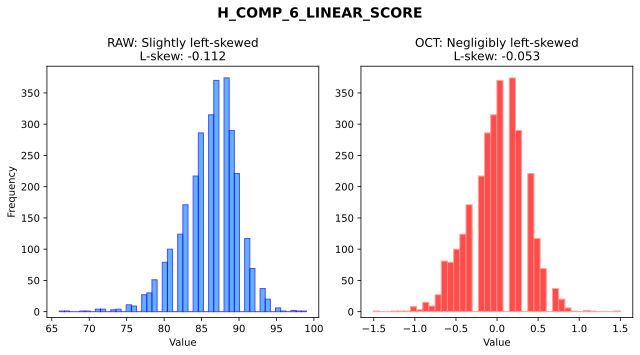




H_QUIET_LINEAR_SCORE         | RAW: Slightly   left-skewed (L-skew = -0.109)
H_QUIET_LINEAR_SCORE         | OCT: Negligibly left-skewed (L-skew = -0.049)
Decrease in absolute skew: 55.2%


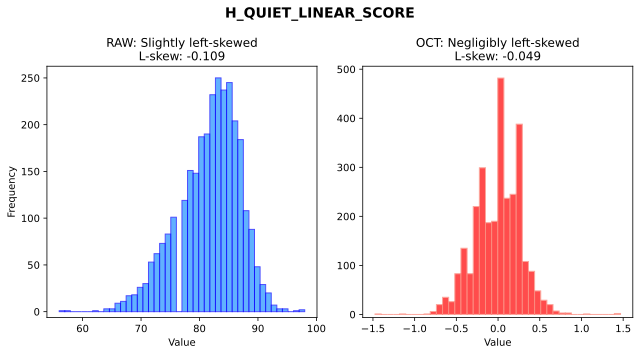




H_RECMND_LINEAR_SCORE        | RAW: Slightly   left-skewed (L-skew = -0.107)
H_RECMND_LINEAR_SCORE        | OCT: Negligibly right-skewed (L-skew = 0.011)
Decrease in absolute skew: 90.0%


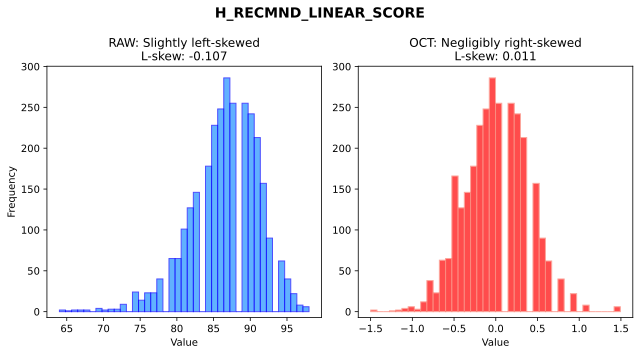




O_COMP_1_LINEAR_SCORE        | RAW: Highly     left-skewed (L-skew = -0.221)
O_COMP_1_LINEAR_SCORE        | OCT: Negligibly left-skewed (L-skew = -0.009)
Decrease in absolute skew: 96.1%


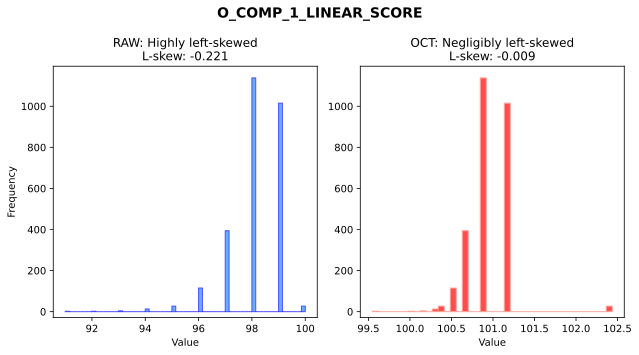




O_COMP_2_LINEAR_SCORE        | RAW: Slightly   left-skewed (L-skew = -0.146)
O_COMP_2_LINEAR_SCORE        | OCT: Negligibly right-skewed (L-skew = 0.008)
Decrease in absolute skew: 94.3%


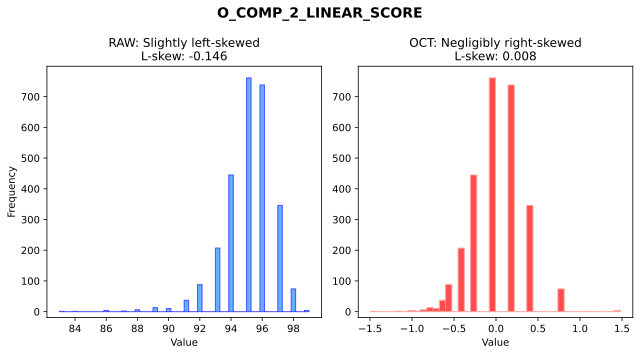




O_COMP_3_LINEAR_SCORE        | RAW: Highly     left-skewed (L-skew = -0.234)
O_COMP_3_LINEAR_SCORE        | OCT: Negligibly left-skewed (L-skew = -0.100)
Decrease in absolute skew: 57.3%


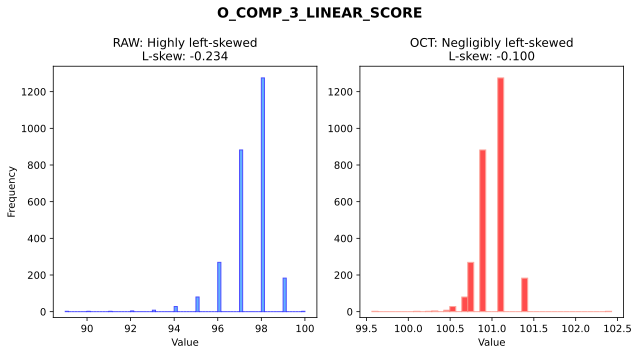




O_PATIENT_RATE_LINEAR_SCORE  | RAW: Slightly   left-skewed (L-skew = -0.137)
O_PATIENT_RATE_LINEAR_SCORE  | OCT: Negligibly left-skewed (L-skew = -0.019)
Decrease in absolute skew: 86.3%


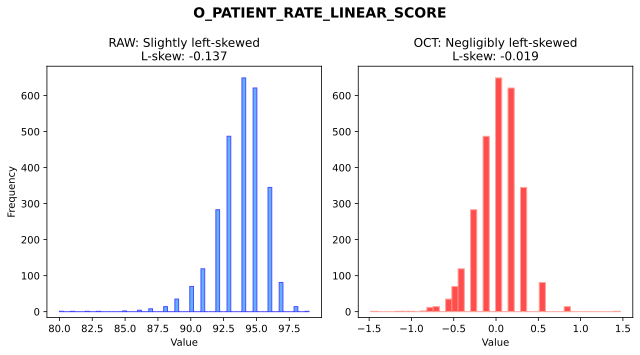




O_PATIENT_REC_LINEAR_SCORE   | RAW: Moderately left-skewed (L-skew = -0.151)
O_PATIENT_REC_LINEAR_SCORE   | OCT: Negligibly left-skewed (L-skew = -0.030)
Decrease in absolute skew: 80.0%


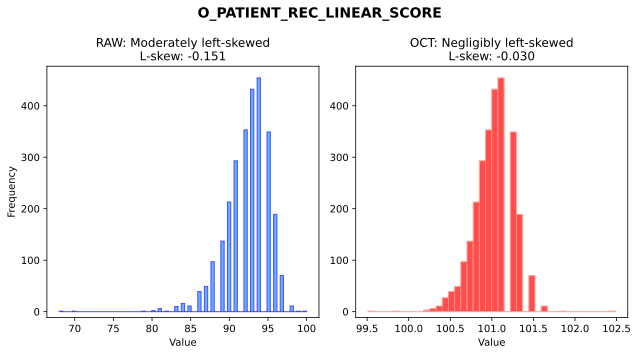

In [7]:
ls = [
    'IMM_3', 'OP_18B', 'OP_22',
    'OP_23', 'OP_29', 'SEP_1',
    'SAFE_USE_OF_OPIOIDS',
    'EDAC_30_AMI', 'EDAC_30_HF', 'EDAC_30_PN',
    'OP_32', 'OP_35_ADM', 'OP_35_ED', 'OP_36',
    'READM_30_CABG', 'READM_30_COPD', 'READM_30_HIP_KNEE', 'Hybrid_HWR',
    'HAI_1', 'HAI_2', 'HAI_3', 'HAI_4', 'HAI_5', 'HAI_6',
    'OP_13', 'OP_8', 'OP_10',
    
    'MORT_30_AMI', 'MORT_30_CABG',
    'MORT_30_COPD', 'MORT_30_HF',
    'MORT_30_PN', 'MORT_30_STK',
    'PSI_4_SURG_COMP', 'COMP_HIP_KNEE', 'PSI_90_SAFETY', 'Hybrid_HWM',
    'H_COMP_1_LINEAR_SCORE', 'H_COMP_2_LINEAR_SCORE',
    'H_COMP_3_LINEAR_SCORE', 'H_COMP_5_LINEAR_SCORE',
    'H_COMP_6_LINEAR_SCORE', 'H_COMP_7_LINEAR_SCORE',
    'H_CLEAN_LINEAR_SCORE', 'H_QUIET_LINEAR_SCORE',
    'H_HSP_RATING_LINEAR_SCORE', 'H_RECMND_LINEAR_SCORE',
    'O_COMP_1_LINEAR_SCORE', 'O_COMP_2_LINEAR_SCORE', 'O_COMP_3_LINEAR_SCORE',
    'O_PATIENT_RATE_LINEAR_SCORE', 'O_PATIENT_REC_LINEAR_SCORE',
    
]

def get_intensity(abs_skew):
    if abs_skew <= 0.1:    return "Negligibly"
    elif abs_skew <= 0.15: return "Slightly"
    elif abs_skew <= 0.2:  return "Moderately"
    elif abs_skew <= 0.3: return "Highly"
    else: return "Extremely"

for lab in ls:
    # 1. Data Preparation
    x_raw = tdf[lab].dropna()
    if len(x_raw) < 3:
        continue
        
    # 2. Raw Metrics
    l_skew_raw = get_skew(x_raw, method='L-moment')
    abs_skew_raw = abs(l_skew_raw)
    intensity_raw = get_intensity(abs_skew_raw)
    direction_raw = ""
    if l_skew_raw > 0:
        direction_raw = "right-skewed" 
    elif l_skew_raw < 0:
        direction_raw = "left-skewed"
    
    # 3. Transformation (OCT)
    # 1. Determine if reflection is needed
    needs_reflection = l_skew_raw < -0.15
    
    if needs_reflection:
        # Shift slightly above max to avoid 0 if OCT requires positive values
        ref_constant = x_raw.max() + 1 
        x_for_oct = ref_constant - x_raw
    else:
        x_for_oct = x_raw.copy()

    # 2. Optimize and Transform
    # Note: We optimize alpha on the 'prepared' (potentially reflected) data
    best_alpha = optimize_OCT_alpha(x_for_oct)
    x_transformed, gl_mean, gl_std, lower, upper = OCT(x_for_oct, alpha=best_alpha)

    # 3. Undo Reflection if it was applied
    if needs_reflection:
        x_oct = ref_constant - x_transformed
    else:
        x_oct = x_transformed
    
    # 4. Transformed Metrics
    l_skew_oct = get_skew(x_oct, method='L-moment')
    abs_skew_oct = abs(l_skew_oct)
    intensity_oct = get_intensity(abs_skew_oct)
    direction_oct = ""
    if l_skew_oct > 0:
        direction_oct = "right-skewed" 
    elif l_skew_oct < 0:
        direction_oct = "left-skewed"
    

    # 5. Reporting Logic
    if abs_skew_raw > 0.1:
        p_c = round(100 * (abs_skew_raw - abs_skew_oct) / abs_skew_raw, 1)
        
        print(f"{lab:<28} | RAW: {intensity_raw:<10} {direction_raw} (L-skew = {l_skew_raw:.3f})")
        print(f"{lab:<28} | OCT: {intensity_oct:<10} {direction_oct} (L-skew = {l_skew_oct:.3f})")
        print(f"Decrease in absolute skew: {p_c}%")
        
        # 6. Visualization (1 Row, 2 Columns)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))
        
        # Left Plot: Raw Data
        counts, bins = np.histogram(x_raw, bins='auto')
        max_count = counts.max()
        bottom_limit = -(max_count * 0.025)
        
        ax1.hist(x_raw, bins=bins, color='dodgerblue', edgecolor='blue', alpha=0.7)
        ax1.set_ylim(bottom=bottom_limit)
        ax1.set_title(f"RAW: {intensity_raw} {direction_raw}\nL-skew: {l_skew_raw:.3f}")
        ax1.set_xlabel("Value")
        ax1.set_ylabel("Frequency")
        
        # Right Plot: OCT Transformed Data
        counts, bins = np.histogram(x_oct, bins='auto')
        max_count = counts.max()
        bottom_limit = -(max_count * 0.025)
        
        n_bins = max(40, int(len(list(set(x_oct))) / 10))
        ax2.hist(x_oct, bins=n_bins, color='red', edgecolor='salmon', alpha=0.7)
        ax2.set_title(f"OCT: {intensity_oct} {direction_oct}\nL-skew: {l_skew_oct:.3f}")
        ax2.set_xlabel("Value")
        ax2.set_ylim(bottom=bottom_limit)
        
        # Super Title for the entire figure
        plt.suptitle(f"{lab}", fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        #print("-" * 150)
        print('\n\n')